**Import Library**

In [25]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**Load Data**

In [26]:
df = pd.read_csv("D:\Semester 3\Text Processing\Projek Akhir\email_spam_indo.csv")
df.head()

,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


In [27]:
jumlah_spam = df[df['Kategori'] == 'spam'].shape[0]
jumlah_ham = df[df['Kategori'] == 'ham'].shape[0]
total_email = df.shape[0]

print("Jumlah Spam :", jumlah_spam)
print("Jumlah Ham  :", jumlah_ham)
print("Total Email :", total_email)

Jumlah Spam : 1368
Jumlah Ham  : 1268
Total Email : 2636


**Preprocessing**

In [28]:
stop_words = set(stopwords.words("indonesian"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    clean = " ".join(tokens)
    return clean

In [29]:
df['clean_text'] = df['Pesan'].apply(preprocess)
df

,Kategori,Pesan,clean_text
0,spam,Secara alami tak tertahankan identitas perusah...,alami tertahankan identitas perusahaan sulit p...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham merrill muz...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...,rumah rumah mudah pemilik rumah disetujui pinj...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...,permintaan khusus pencetakan warna informasi t...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak...",uang dapatkan cd perangkat lunak kompatibilita...
...,...,...,...
2631,ham,Pengingat halo semuanya: Vince telah meminta s...,pengingat halo vince mengirim pengingat pengin...
2632,ham,Re: Argentina Power & Gas Market Modeling Oke ...,re argentina power gas market modeling oke jul...
2633,ham,"Re: Program Enron / Stanford Stinson, hebat! S...",re program enron stanford stinson hebat kolabo...
2634,ham,"Persetujuan untuk peninjau Roberts JR, Michael...",persetujuan peninjau roberts jr michael a meny...


**WordCloud**

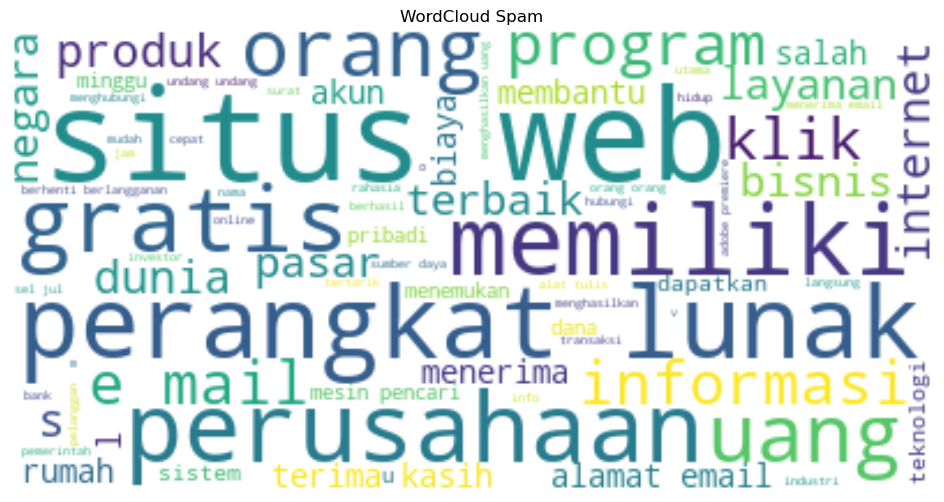

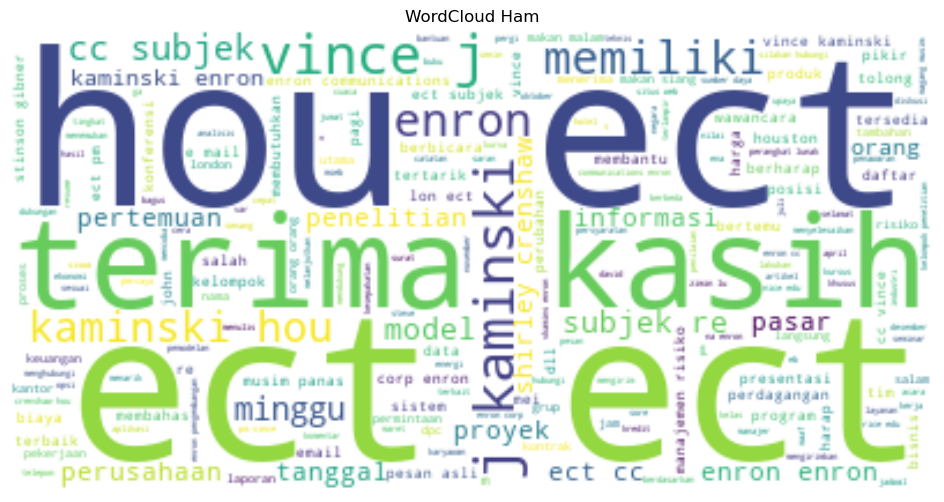

In [30]:
spam_text = " ".join(df[df['Kategori'] == 'spam']['clean_text'])
ham_text  = " ".join(df[df['Kategori'] == 'ham']['clean_text'])

plt.figure(figsize=(12,6))
plt.title("WordCloud Spam")
plt.imshow(WordCloud(background_color='white').generate(spam_text), interpolation='bilinear')
plt.axis("off")
plt.show()

plt.figure(figsize=(12,6))
plt.title("WordCloud Ham")
plt.imshow(WordCloud(background_color='white').generate(ham_text), interpolation='bilinear')
plt.axis("off")
plt.show()

**Analisis Kata**

In [31]:
from collections import Counter
spam_words = " ".join(df[df['Kategori']=='spam']['clean_text']).split()
ham_words  = " ".join(df[df['Kategori']=='ham']['clean_text']).split()

spam_freq = Counter(spam_words).most_common(20)
ham_freq  = Counter(ham_words).most_common(20)

spam_df = pd.DataFrame(spam_freq, columns=['word','count'])
ham_df  = pd.DataFrame(ham_freq, columns=['word','count'])

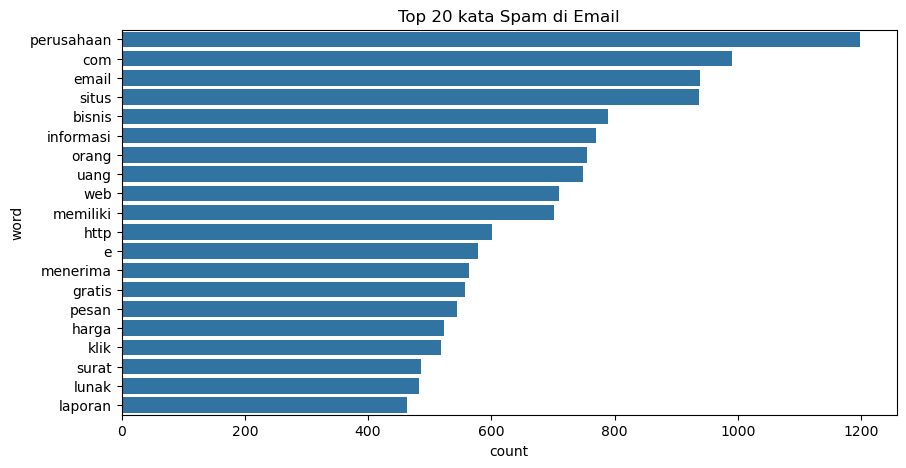

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=spam_df)
plt.title("Top 20 kata Spam di Email")
plt.show()

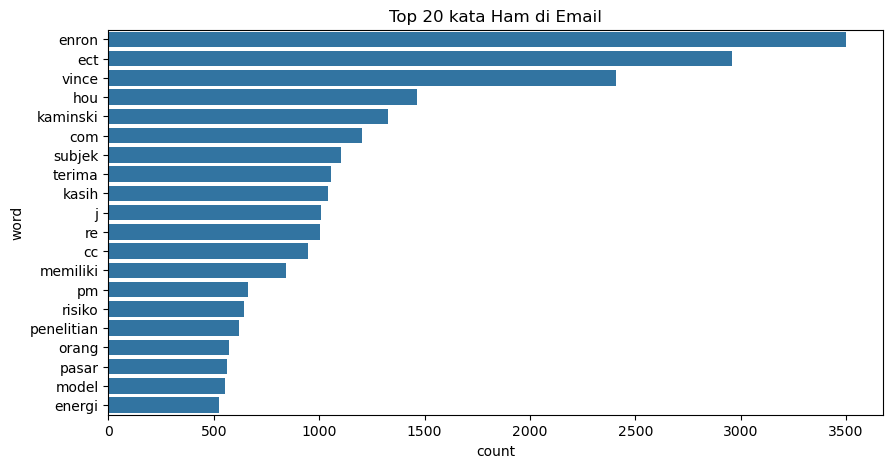

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=ham_df)
plt.title("Top 20 kata Ham di Email")
plt.show()

**Distribusi Panjang Email**

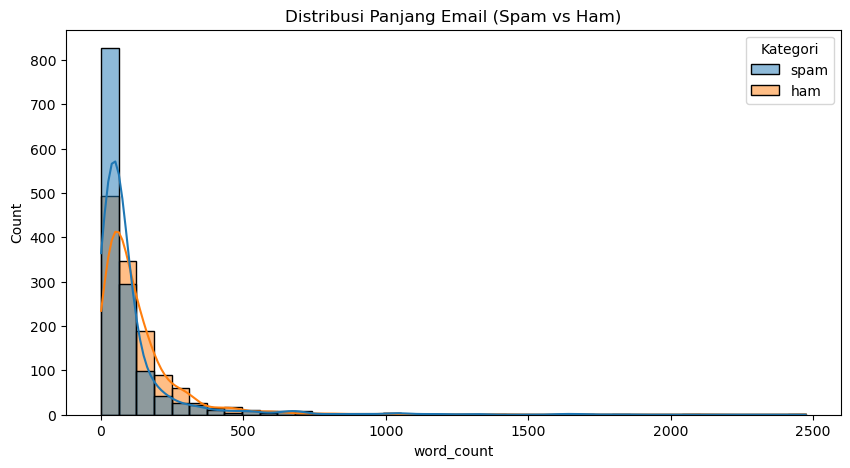

In [34]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='word_count', hue='Kategori', kde=True, bins=40)
plt.title("Distribusi Panjang Email (Spam vs Ham)")
plt.show()

**Split Train-Test**

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['Kategori'], test_size=0.2, random_state=42
)

**TF-IDF**

In [36]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

**Bag of Words (BoW)**

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

**Model Naive Bayes**

In [38]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [39]:
model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


**Evaluasi**

In [40]:
y_pred = model.predict(X_test_vec)

print("Confusion Matrix (TF-IDF)")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report (TF-IDF)")
print(classification_report(y_test, y_pred))

Confusion Matrix (TF-IDF)
[[257   6]
 [  1 264]]

Classification Report (TF-IDF)
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99       263
        spam       0.98      1.00      0.99       265

    accuracy                           0.99       528
   macro avg       0.99      0.99      0.99       528
weighted avg       0.99      0.99      0.99       528



In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_bow = model_bow.predict(X_test_bow)

print("Confusion Matrix (BoW)")
print(confusion_matrix(y_test, y_pred_bow))

print("\nClassification Report (BoW)")
print(classification_report(y_test, y_pred_bow))

Confusion Matrix (BoW)
[[259   4]
 [  2 263]]

Classification Report (BoW)
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       263
        spam       0.99      0.99      0.99       265

    accuracy                           0.99       528
   macro avg       0.99      0.99      0.99       528
weighted avg       0.99      0.99      0.99       528



**Perbandingan Akurasi TF-IDF & BoW**

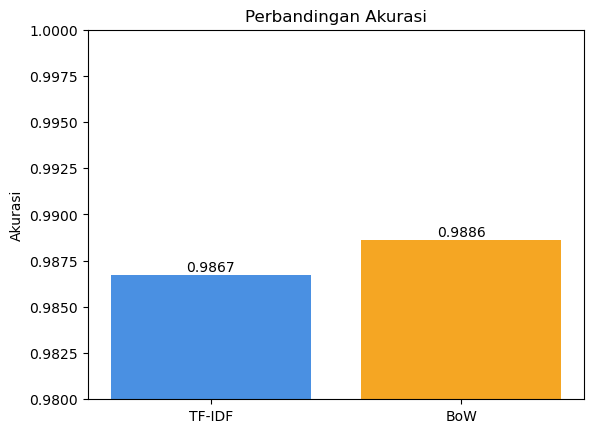

In [ ]:
from sklearn.metrics import accuracy_score

acc_tfidf = accuracy_score(y_test, y_pred)
acc_bow = accuracy_score(y_test, y_pred_bow)

plt.bar(["TF-IDF", "BoW"], [acc_tfidf, acc_bow], color=["#4a90e2", "#f5a623"])
plt.title("Perbandingan Akurasi")
plt.ylabel("Akurasi")
plt.ylim(0.98,1.00)
for i, acc in enumerate([acc_tfidf, acc_bow]):
    plt.text(i, acc + 0.0002, f"{acc:.4f}", ha='center')
plt.show()

**Perbandingan Log Probabilitas Kata**

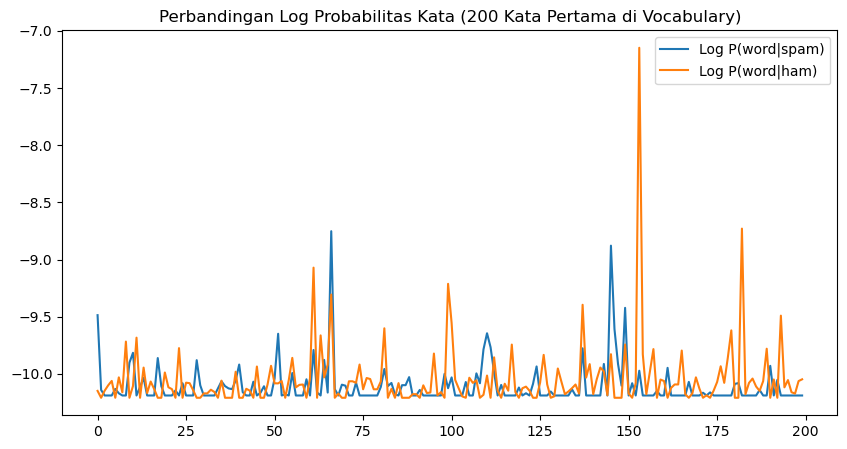

In [43]:
log_prob_spam = model.feature_log_prob_[0]
log_prob_ham  = model.feature_log_prob_[1]

plt.figure(figsize=(10,5))
plt.plot(log_prob_spam[:200], label="Log P(word|spam)")
plt.plot(log_prob_ham[:200], label="Log P(word|ham)")
plt.title("Perbandingan Log Probabilitas Kata (200 Kata Pertama di Vocabulary)")
plt.legend()
plt.show()

**Simpen Model**

In [44]:
joblib.dump(model, "nb_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

**Prediksi New Email**

In [56]:
def evaluate_external(emails):
    cleaned = [preprocess(e) for e in emails]
    vec = vectorizer.transform(cleaned)
    preds = model.predict(vec)
    return list(zip(emails, preds))

email = [
    "Selamat! Anda memenangkan hadiah 50 juta rupiah segera klik link berikut",
    "Halo, apakah besok ada kelas?",
    "Promo diskon 90% untuk pembelian aplikasi premium",
    "Mohon kirimkan laporan bulan ini ya"
]

evaluate_external(email)

[('Selamat! Anda memenangkan hadiah 50 juta rupiah segera klik link berikut',
  np.str_('spam')),
 ('Halo, apakah besok ada kelas?', np.str_('ham')),
 ('Promo diskon 90% untuk pembelian aplikasi premium', np.str_('spam')),
 ('Mohon kirimkan laporan bulan ini ya', np.str_('ham'))]

**cek overfit**

In [46]:
train_pred = model.predict(X_train_vec)
print("Train akurasi:", (train_pred == y_train).mean())

test_pred = model.predict(X_test_vec)
print("Test akurasi:", (test_pred == y_test).mean())

Train akurasi: 0.9947817836812144
Test akurasi: 0.9867424242424242


In [47]:
train_pred = model.predict(X_train_bow)
print("Train akurasi:", (train_pred == y_train).mean())

test_pred = model.predict(X_test_bow)
print("Test akurasi:", (test_pred == y_test).mean())

Train akurasi: 0.9933586337760911
Test akurasi: 0.9867424242424242


**Cross Validation**

In [55]:
from sklearn.model_selection import cross_val_score

skor = cross_val_score(model, vectorizer.transform(df['clean_text']), df['Kategori'], cv=5)
print(skor)
print("Rata-rata CV akurasi:", skor.mean())

[0.9905303  0.98481973 0.9829222  0.9886148  0.98481973]
Rata-rata CV akurasi: 0.9863413547237077
